# Physical Activity vs. Sleep Duration: A Data-Driven Analysis

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [  ] YES - make available
* [ X ] NO - keep private

## Link to video
https://link.to.your.publicly.viewable.video

## Abstract

This project investigates the relationship between duration of daily physical activity and sleep duration in individuals aged 16 and older. Sleep is a vital aspect of maintaining health as it influences emotional and physical well-being as well as cognitive functionality. More specifically, sleep duration is a key indicator of sleep quality and therefore also drives overall health. Previous research suggests that lifestyle behaviors such as exercise may impact sleep quality, so this project specifically aims to study whether increased physical activity is associated with longer and more adequate sleep duration.

In order to explore this question, we analyzed datasets containing information on individuals’ physical activity levels and sleep patterns. These datasets were cleaned, merged, and processed to compute key metrics such as total weekly physical activity and average sleep duration. Sleep quality was measured based on whether individuals met the recommended sleep guidelines of 7–9 hours per night. Both exploratory data analysis (i.e. correlation heatmaps, scatterplots, etc) and statistical methods were used to examine relationships between these variables.

Our findings indicate that physical activity duration and sleep duration have little to no strong linear correlation. There were no clear trends illustrated across physical activity levels, implying that there is an extremely weak relationship between the two variables. On the other hand, patterns in our heatmap suggest that healthier lifestyle factors such as regular activity and a lower BMI may be strongly associated with better sleep outcomes. Although our findings did not support the hypothesis that increased physical activity duration leads to increased sleep duration, the results highlight that sleep duration is likely influenced by a combination of lifestyle factors rather than physical activity alone. This study highlights the need for further multivariable analyses in future research. Future studies should also examine the type and intensity of physical activity as these characteristics may reveal a stronger correlation between sleep duration and physical activity. 



## Authors

**Sindhu Dhulipala**: Dataset sourcing, data wrangling, dataset merging, scatterplot creation, and analysis  

**Anwesha Mohanty**: Dataset sourcing, data wrangling, abstract and research question, correlation heatmap 

**Akshitaa Balasai**: Scatterplot analysis, correlation heatmap analysis, data wrangling, and discussion and conclusion writing  

**Ryan Kasem**: Background research, hypothesis and rationale development, discussion and conclusion writing, and ethics  

**Hasnain Farishta**: Background research, hypothesis and rationale development, discussion and conclusion writing, and ethics  

## Research Question

How does the total duration of daily physical activity affect sleep duration in adults aged 16 and older?

In this study, sleep quality is defined based on whether an individual’s average sleep duration meets medically recommended levels for adult functional health.

- Sleep duration is calculated using the total minutes asleep recorded in the dataset.
- Values are evaluated relative to standard adult sleep recommendations (approximately **7–9 hours per night**).



## Background and Prior Work

Sleep plays an important role in overall health because it helps the brain and body function properly each day. Getting enough sleep supports memory, concentration, metabolism, and general productivity. On the other hand, not getting enough sleep can lead to problems such as weakened immunity, mood changes, and mental health concerns. Since sleep affects so many parts of daily life, researchers often study what habits might improve or worsen sleep.

Sleep quality can mean different things, but in this project it is defined specifically as sleep duration, or how many hours a person sleeps. Previous research shows that consistently short sleep duration is linked to higher risks of weight gain, heart disease, stroke, anxiety, and depression.<sup>1</sup> Because of these risks, it is useful to understand which behaviors are connected to sleeping longer or shorter amounts of time.

Several lifestyle factors may influence sleep duration, including diet, screen use, and physical activity.<sup>2</sup> Physical activity is especially important because it affects both energy levels and the body’s natural sleep cycle. Studies suggest that people who exercise regularly, especially through daily movement or cardiovascular activity, tend to sleep longer and more consistently than those who are inactive.<sup>2</sup> This suggests that an active routine may support healthier sleep patterns.

For example, a study of undergraduate students in China found that students who exercised less and spent more time on screens before bed reported worse sleep outcomes.<sup>3</sup> This supports the idea that daily activity levels may be connected to how long people sleep. Building on this idea, this project will examine how the total duration of daily physical activity relates to sleep duration in adults aged 16 and older. Other factors such as age, gender, occupation, BMI, and blood pressure will also be considered to better understand the relationship between activity and sleep.

## Hypothesis




We hypothesize that average sleep duration on weekdays (in minutes per night) will be shorter for those with higher BMI, advancing age, and higher blood pressure than for those with more favorable values of these variables. Specifically, we hypothesize that those who are classified as overweight or obese will have shorter average sleep duration on weekdays than those who have a normal BMI.

We also hypothesize that physical activity will be positively related to sleep duration. Those who accumulate fewer total minutes of physical activity per week will have shorter average sleep duration than those who accumulate the recommended 150 minutes per week. Furthermore, we hypothesize that sleep duration will vary by gender and occupation category, especially for those in more sedentary or stressful occupations.

**Rationale**

Sleep duration (in minutes per night) is affected by both physical health and daily lifestyle factors. A higher BMI is commonly associated with health issues like sleep apnea and breathing disturbances that can lead to lower overall sleep duration. As people grow older, their sleep patterns can become more fragmented, leading to lower overall sleep duration per night. High blood pressure can be an indicator of stress or other health issues that can disrupt sleep.

Physical activity can help promote healthier sleep patterns by controlling energy levels and the body’s natural sleep cycle. People who are more active on a weekly basis may have longer sleep duration than people who are less active. By analyzing sleep in minutes per night and activity in minutes per week, we can see if these factors are significantly related to sleep duration.


## Data

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- run once after cloning the repo

import sys
sys.path.append('./modules')

import get_data

# Use the direct CDC file paths (these work properly with requests)
datafiles = [
    {
        "url": "https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/SLQ_J.XPT?download",
        "filename": "SLQ_J.XPT"
    },
    {
        "url": "https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/PAQ_J.XPT?download",
        "filename": "PAQ_J.XPT"
    }
]

get_data.get_raw(datafiles, destination_directory="data/00-raw/")

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  2.17it/s]

Successfully downloaded: SLQ_J.XPT


Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  2.23it/s]

Successfully downloaded: PAQ_J.XPT


# Sleep Patterns & Disorders

**Dataset Name:**  
NHANES 2017–2018 Sleep Disorders Questionnaire (SLQ_J)

**Link to the Dataset:**  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SLQ_J.htm

**Number of Observations:**  
6,161 participants  

The SLQ_J file includes 6,161 individuals aged 16 years and older who completed the sleep questionnaire during the 2017–2018 NHANES cycle. Because NHANES uses a complex, multistage probability sampling design, these data are nationally representative of the civilian, non-institutionalized U.S. population. The 6,161 records represent all respondents in this cycle who provided sleep questionnaire data prior to merging or cleaning procedures.

**Number of Variables:**  
11 variables  

The dataset contains the following variables:

- **SEQN** – Respondent sequence number (unique participant ID)
- **SLQ300** – Usual sleep time on weekdays/workdays
- **SLQ310** – Usual wake time on weekdays/workdays
- **SLQ320** – Usual sleep time on weekends/non-workdays
- **SLQ330** – Usual wake time on weekends/non-workdays
- **SLD012** – Usual sleep duration on weekdays (hours)
- **SLD013** – Usual sleep duration on weekends (hours)
- **SLQ040** – Ever told by a doctor that you have a sleep disorder
- **SLQ050** – Trouble sleeping
- **SLQ060** – Ever told by a doctor that you have sleep apnea
- **SLQ070** – Snoring frequency

For this project, we focus primarily on the sleep timing and sleep duration variables (SLQ300–SLQ330, SLD012, and SLD013).

**Description of Variables Most Relevant to This Project:**

Although the dataset contains 11 variables, our analysis centers on sleep timing and duration patterns.

Primary variables include:

- **Weekday Bedtime (SLQ300)** – Usual time participant goes to sleep on weekdays/workdays (clock time).
- **Weekday Wake Time (SLQ310)** – Usual time participant wakes up on weekdays/workdays.
- **Weekend Bedtime (SLQ320)** – Usual time participant goes to sleep on weekends/non-workdays.
- **Weekend Wake Time (SLQ330)** – Usual time participant wakes up on weekends/non-workdays.

Using these timing variables, we derive:

- Weekday sleep duration (hours)
- Weekend sleep duration (hours)
- Difference between weekday and weekend sleep timing (indicator of social jet lag / circadian misalignment)

We also analyze:

- **SLD012** – Self-reported weekday sleep duration (hours per night)
- **SLD013** – Self-reported weekend sleep duration (hours per night)

Sleep duration is reported in **hours per night**.

For adults:
- 7–9 hours → Recommended healthy sleep range
- Less than 7 hours → Associated with increased risk of cardiovascular disease, obesity, diabetes, cognitive impairment, and mortality
- Less than 5–6 hours → Considered very short sleep and may indicate elevated health risk
- Greater than 9–10 hours → May also be associated with adverse health outcomes

Large differences between weekday and weekend sleep timing may reflect social jet lag, which has been linked to metabolic and mental health risks.

**Shortcomings of the Dataset:**

1. **Self-Reported Sleep Measures**  
All sleep measures are self-reported, which may introduce recall bias and rounding error (for example, reporting 10:00 PM instead of 9:47 PM). Self-reported sleep duration typically overestimates true sleep compared to objective measures such as actigraphy or wearable sleep trackers. The dataset does not measure sleep quality, awakenings, restfulness, or sleep stages.

2. **Missing and Uncertain Responses**  
Some responses include “Don’t Know,” “Refused,” or placeholder values. These were recoded as NaN during cleaning. Removing incomplete responses may slightly affect representativeness.

3. **Time Conversion**  
Sleep duration was originally reported in hours and converted to minutes for alignment with the physical activity dataset. Biologically implausible values (less than or equal to 0 or greater than 24 hours) were removed during cleaning to ensure accuracy and consistency.


In [3]:
import pandas as pd
import numpy as np

# ⚠️ IMPORTANT:
# Change this base_path to match YOUR computer's file location
# Each group member must update this to their own data folder.

base_path = "/Users/sindhudhulipala/Documents/COGS_sleep_project/data/00-raw/"

# Load only needed columns from sleep dataset
sleep_df = pd.read_sas(
    base_path + "SLQ_J.XPT.txt",
    format="xport"
)[["SEQN", "SLD012", "SLD013"]]

# Replace SAS missing value code with NaN
sleep_df = sleep_df.replace(5.397605e-79, np.nan)

# Rename columns for clarity
sleep_df = sleep_df.rename(columns={
    "SEQN": "participant_id",
    "SLD012": "weekday_sleep_hours",
    "SLD013": "weekend_sleep_hours"
})

print("Sleep dataset shape:", sleep_df.shape)
sleep_df.head()


Sleep dataset shape: (6161, 3)


,participant_id,weekday_sleep_hours,weekend_sleep_hours
0,93705.0,8.0,8.0
1,93706.0,10.5,11.5
2,93708.0,8.0,8.0
3,93709.0,7.0,6.5
4,93711.0,7.0,9.0


# Physical Activity Patterns

**Dataset Name:**  
National Health and Nutrition Examination Survey Physical Activity Questionnaire (PAQ_J)

**Link to the Dataset:**  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/PAQ_J.xpt  

**Dataset Description Page:**  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/PAQ_J.htm  

**Number of Observations:**  
5,856 participants  

**Number of Variables:**  
17 variables (analysis uses 2)

The NHANES Physical Activity Questionnaire (PAQ_J) provides measures of physical activity patterns among U.S. adults. The questionnaire includes variables measuring weekly physical activity such as minutes and number of days performing both moderate- and vigorous-intensity activity. By combining moderate and vigorous activity minutes, participants can be categorized as sedentary, insufficiently active, or meeting recommended public health guidelines.

Although the dataset contains 17 total variables describing physical activity frequency and duration, this project focuses specifically on two measures:

- **PAD615 – Vigorous Physical Activity Minutes**  
  Reports the number of minutes per week participants engage in vigorous-intensity activities. These activities substantially increase breathing or heart rate (e.g., running, cycling, heavy labor).

- **PAQ620 – Moderate Physical Activity Minutes**  
  Reports the number of minutes per week participants engage in moderate-intensity activities. These activities moderately increase breathing or heart rate (e.g., brisk walking, light labor, household tasks).

From these two variables, we calculate:

- **Total Physical Activity Minutes = Vigorous Minutes + Moderate Minutes**

Physical activity is measured in **minutes per week**. Public health guidelines recommend that adults perform at least **150 minutes per week** of moderate-intensity activity (or equivalent). Values below 150 minutes indicate low or insufficient activity levels, while values substantially above 150 minutes indicate highly active individuals.

**Shortcomings of the Dataset:**

1. **Self-Reported Data**  
   All activity measures are self-reported survey responses. Participants may overestimate or underestimate their activity levels due to recall bias or social desirability bias. Self-reported activity often exceeds objectively measured activity from wearable devices.

2. **Short-Term Reporting**  
   The questionnaire reflects a typical recent week rather than long-term activity patterns. Factors such as illness, travel, work demands, or seasonal changes may temporarily influence reported activity.

3. **Missing or Uncertain Responses**  
   Some responses include missing or uncertain values that require cleaning. Removing incomplete observations may slightly reduce representativeness.

4. **Population Coverage**  
   NHANES represents the non-institutionalized U.S. population. Hospitalized individuals, active-duty military personnel, and long-term care residents are excluded, which may slightly bias national activity estimates.

5. **No Frequency Distribution Across Days**  
   The dataset reports total weekly minutes but does not specify how activity is distributed across days. For analysis purposes, daily activity may be estimated by dividing weekly minutes by 7; however, this assumes activity is evenly distributed. In reality, some participants may concentrate activity into one or two days, which could affect sleep outcomes differently.


In [4]:
# ============================================================
# LOAD + CLEAN NHANES PHYSICAL ACTIVITY DATA (PAQ_J)
# ============================================================

import pandas as pd
import numpy as np

# ⚠️ UPDATE THIS PATH IF NEEDED
BASE_PATH = "/Users/sindhudhulipala/Documents/COGS_sleep_project/data/00-raw/"
# Each team member should update this to their own data folder

# Load only relevant columns
activity_df = pd.read_sas(
    BASE_PATH + "PAQ_J.XPT.txt",
    format="xport"
)[["SEQN", "PAD615", "PAQ620"]]

# Replace SAS missing value code
activity_df = activity_df.replace(5.397605e-79, np.nan)

# Rename columns
activity_df = activity_df.rename(columns={
    "SEQN": "participant_id",
    "PAD615": "vigorous_minutes_week",
    "PAQ620": "moderate_minutes_week"
})

# Remove negative or implausible values
activity_df = activity_df[
    (activity_df["vigorous_minutes_week"] >= 0) &
    (activity_df["moderate_minutes_week"] >= 0)
].copy()

# Create total physical activity variable
activity_df["total_activity_minutes_week"] = (
    activity_df["vigorous_minutes_week"] +
    activity_df["moderate_minutes_week"]
)

# Create guideline indicator (150 min per week threshold)
activity_df["meets_activity_guidelines"] = np.where(
    activity_df["total_activity_minutes_week"] >= 150, 1, 0
)

print("Activity dataset shape:", activity_df.shape)
activity_df.head()


Activity dataset shape: (1381, 5)


,participant_id,vigorous_minutes_week,moderate_minutes_week,total_activity_minutes_week,meets_activity_guidelines
5,93712.0,420.0,1.0,421.0,1
8,93715.0,600.0,1.0,601.0,1
14,93723.0,60.0,1.0,61.0,0
23,93738.0,480.0,1.0,481.0,1
26,93743.0,360.0,1.0,361.0,1


### Merging the Sleep and Physical Activity Datasets

The NHANES Sleep Questionnaire (SLQ_J) and the Physical Activity Questionnaire (PAQ_J) datasets measure different aspects of health but are collected from the same survey participants. Each dataset contains the unique participant identifier **SEQN**, which allows variables from separate questionnaires to be linked for the same individuals.

Although the sleep dataset does not contain physical activity variables and the activity dataset does not contain sleep variables, both datasets refer to the same participants in the NHANES survey. By merging them on the shared identifier **SEQN**, we combine sleep measurements and physical activity measurements for each individual.

This merge allows us to create a single dataset where each row represents one participant with both their sleep duration and their physical activity levels. This combined dataset enables us to examine whether differences in physical activity are associated with variations in sleep duration.

Without merging the datasets, we would only be able to analyze sleep and physical activity separately. Merging them makes it possible to study the **individual-level relationship between physical activity and sleep duration**, which is necessary to answer our research question.

In [5]:
# ============================================================
# MERGING PHYSICAL ACTIVITY AND SLEEP DATASETS
# ============================================================

# ---------- 1. Clean Sleep Data Further ----------

# Remove biologically impossible sleep values (must be >0 and <=24 hours)
sleep_df = sleep_df[
    (sleep_df["weekday_sleep_hours"] > 0) &
    (sleep_df["weekday_sleep_hours"] <= 24) &
    (sleep_df["weekend_sleep_hours"] > 0) &
    (sleep_df["weekend_sleep_hours"] <= 24)
].copy()

# Convert sleep hours to minutes
sleep_df["weekday_sleep_minutes"] = sleep_df["weekday_sleep_hours"] * 60
sleep_df["weekend_sleep_minutes"] = sleep_df["weekend_sleep_hours"] * 60

# Calculate difference between weekend and weekday sleep (social jet lag)
sleep_df["sleep_difference_minutes"] = (
    sleep_df["weekend_sleep_minutes"] -
    sleep_df["weekday_sleep_minutes"]
)

# ---------- 2. Ensure Activity Data Is Clean ----------

activity_df = activity_df.copy()

# Replace missing values with 0 (no reported activity)
activity_df["vigorous_minutes_week"] = activity_df["vigorous_minutes_week"].fillna(0)
activity_df["moderate_minutes_week"] = activity_df["moderate_minutes_week"].fillna(0)

# Recalculate total activity
activity_df["total_activity_minutes_week"] = (
    activity_df["vigorous_minutes_week"] +
    activity_df["moderate_minutes_week"]
)

# ---------- 3. Merge Datasets ----------

# Merge on participant ID (inner join keeps only participants in both datasets)
final_df = pd.merge(
    sleep_df,
    activity_df,
    on="participant_id",
    how="inner"
)

# ---------- 4. Final Dataset Cleanup ----------

# Drop any remaining rows with missing key variables
final_df = final_df.dropna(subset=[
    "weekday_sleep_minutes",
    "weekend_sleep_minutes",
    "total_activity_minutes_week"
])

print("Final merged dataset shape:", final_df.shape)
final_df.head()


Final merged dataset shape: (1363, 10)


,participant_id,weekday_sleep_hours,weekend_sleep_hours,weekday_sleep_minutes,weekend_sleep_minutes,sleep_difference_minutes,vigorous_minutes_week,moderate_minutes_week,total_activity_minutes_week,meets_activity_guidelines
0,93712.0,7.5,9.0,450.0,540.0,90.0,420.0,1.0,421.0,1
1,93715.0,5.0,5.0,300.0,300.0,0.0,600.0,1.0,601.0,1
2,93723.0,6.0,7.0,360.0,420.0,60.0,60.0,1.0,61.0,0
3,93738.0,7.0,7.5,420.0,450.0,30.0,480.0,1.0,481.0,1
4,93743.0,5.5,9.5,330.0,570.0,240.0,360.0,1.0,361.0,1


## Results

#### Data Validation 

To ensure the merged dataset is consistent and ready for analysis, we perform additional validation checks including dataset shape verification, missing value inspection, and summary statistics.

### Dataset Structure

We first inspect the structure of each dataset to confirm that the data loaded correctly and to understand the variables available for analysis. This includes checking the number of rows and columns in each dataset, reviewing the variable names, and previewing the first few rows of data.

The datasets examined are:
- sleep_df (sleep duration information)
- activity_df (physical activity data)
- final_df (merged dataset used for analysis)

In [6]:
print("Sleep DataFrame Shape:", sleep_df.shape)
print("Sleep DataFrame Columns:", sleep_df.columns)
sleep_df.head()

print("\nActivity DataFrame Shape:", activity_df.shape)
print("Activity DataFrame Columns:", activity_df.columns)
activity_df.head()

print("\nFinal DataFrame Shape:", final_df.shape)
print("Final DataFrame Columns:", final_df.columns)
final_df.head()

Sleep DataFrame Shape: (6090, 6)
Sleep DataFrame Columns: Index(['participant_id', 'weekday_sleep_hours', 'weekend_sleep_hours',
       'weekday_sleep_minutes', 'weekend_sleep_minutes',
       'sleep_difference_minutes'],
      dtype='object')

Activity DataFrame Shape: (1381, 5)
Activity DataFrame Columns: Index(['participant_id', 'vigorous_minutes_week', 'moderate_minutes_week',
       'total_activity_minutes_week', 'meets_activity_guidelines'],
      dtype='object')

Final DataFrame Shape: (1363, 10)
Final DataFrame Columns: Index(['participant_id', 'weekday_sleep_hours', 'weekend_sleep_hours',
       'weekday_sleep_minutes', 'weekend_sleep_minutes',
       'sleep_difference_minutes', 'vigorous_minutes_week',
       'moderate_minutes_week', 'total_activity_minutes_week',
       'meets_activity_guidelines'],
      dtype='object')


,participant_id,weekday_sleep_hours,weekend_sleep_hours,weekday_sleep_minutes,weekend_sleep_minutes,sleep_difference_minutes,vigorous_minutes_week,moderate_minutes_week,total_activity_minutes_week,meets_activity_guidelines
0,93712.0,7.5,9.0,450.0,540.0,90.0,420.0,1.0,421.0,1
1,93715.0,5.0,5.0,300.0,300.0,0.0,600.0,1.0,601.0,1
2,93723.0,6.0,7.0,360.0,420.0,60.0,60.0,1.0,61.0,0
3,93738.0,7.0,7.5,420.0,450.0,30.0,480.0,1.0,481.0,1
4,93743.0,5.5,9.5,330.0,570.0,240.0,360.0,1.0,361.0,1


### Summary Statistics

We compute summary statistics to better understand the distribution of variables in the merged dataset. These statistics include measures such as the mean, standard deviation, minimum, and maximum values, providing a quick overview of the dataset.

In [7]:
print("Summary statistics for final dataset:")
final_df.describe()

Summary statistics for final dataset:


,participant_id,weekday_sleep_hours,weekend_sleep_hours,weekday_sleep_minutes,weekend_sleep_minutes,sleep_difference_minutes,vigorous_minutes_week,moderate_minutes_week,total_activity_minutes_week,meets_activity_guidelines
count,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000
mean,98251.327219,7.328687,8.206530,439.721203,492.391783,52.670580,228.582539,1.171680,229.754219,0.504769
std,2680.896553,1.653823,1.838787,99.229388,110.327249,111.551859,554.417270,0.377241,554.410256,0.500161
min,93712.000000,2.000000,2.000000,120.000000,120.000000,-360.000000,10.000000,1.000000,11.000000,0.000000
25%,95848.000000,6.500000,7.000000,390.000000,420.000000,0.000000,60.000000,1.000000,61.000000,0.000000
50%,98198.000000,7.500000,8.000000,450.000000,480.000000,30.000000,180.000000,1.000000,181.000000,1.000000
75%,100557.500000,8.000000,9.000000,480.000000,540.000000,120.000000,300.000000,1.000000,301.000000,1.000000
max,102953.000000,14.000000,14.000000,840.000000,840.000000,540.000000,9999.000000,2.000000,10000.000000,1.000000


### Missing Value Inspection

We also check for missing values across the datasets to identify potential issues that may affect analysis. Understanding the extent of missing data helps determine whether further cleaning steps are necessary.

In [8]:
print("Missing values in sleep dataset:")
print(sleep_df.isnull().sum())

print("\nMissing values in activity dataset:")
print(activity_df.isnull().sum())

print("\nMissing values in final dataset:")
print(final_df.isnull().sum())


Missing values in sleep dataset:
participant_id              0
weekday_sleep_hours         0
weekend_sleep_hours         0
weekday_sleep_minutes       0
weekend_sleep_minutes       0
sleep_difference_minutes    0
dtype: int64

Missing values in activity dataset:
participant_id                 0
vigorous_minutes_week          0
moderate_minutes_week          0
total_activity_minutes_week    0
meets_activity_guidelines      0
dtype: int64

Missing values in final dataset:
participant_id                 0
weekday_sleep_hours            0
weekend_sleep_hours            0
weekday_sleep_minutes          0
weekend_sleep_minutes          0
sleep_difference_minutes       0
vigorous_minutes_week          0
moderate_minutes_week          0
total_activity_minutes_week    0
meets_activity_guidelines      0
dtype: int64


### Initial EDA Summary

The exploratory analysis confirms that the datasets are structured correctly and contain the variables necessary for analyzing sleep duration and physical activity. The summary statistics provide an overview of the distributions, and the missing value inspection highlights any potential data quality issues. These checks ensure the dataset is ready for further visualization and analysis in later sections.

#### Distribution of Sleep Duration

To better understand the sleep patterns in our dataset, we first examine the distribution of sleep duration among participants. 
The NHANES sleep dataset records the number of hours individuals report sleeping on weekdays and weekends. 
Understanding the distribution of sleep duration helps identify common sleep patterns and detect unusually short or long sleep durations. 
Since recommended sleep for adults is approximately 7–9 hours per night, this visualization allows us to see how closely the sample follows these guidelines.

### Box Plot of Sleep Duration Spread
A box plot was used to further examine the distribution of weekday sleep duration because it provides a clear summary of the data and makes it easy to identify the median, spread of the data, and any potential outliers. This helps us better understand how sleep duration varies across participants and whether there are unusually low or high values that may influence the analysis.

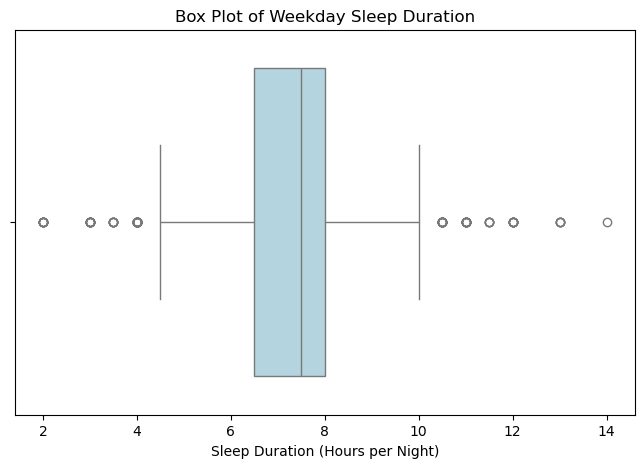

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x = final_df["weekday_sleep_minutes"] / 60,
    color = "lightblue"
)

plt.title("Box Plot of Weekday Sleep Duration")
plt.xlabel("Sleep Duration (Hours per Night)")

plt.show()

A box plot was used to further examine the distribution of weekday sleep duration because it provides a clear summary of the data and makes it easy to identify the median, spread of the data, and any potential outliers. This helps us better understand how sleep duration varies across participants and whether there are unusually low or high values that may influence the analysis.

From the plot, the median sleep duration appears to be around 7.5–8 hours per night, which falls within the recommended 7–9 hours of sleep for adults. The middle 50% of participants seem to sleep roughly between about 6.5 and 8.5 hours on weekdays.

The plot also shows several outliers on both ends of the distribution, with some participants reporting very short sleep durations of around 2–4 hours and others reporting much longer durations of 10 hours or more. Overall, while most participants appear to fall within a typical sleep range, there is still noticeable variation in sleep duration, which may help us explore whether differences in physical activity levels are related to sleep patterns.

### Correlation Heat Map of Sleep vs Physical Activity

We also wanted to study and potentially recognize any relationships between other variables in our dataset. Therefore, we created a correlation heat map of all of the numeric variables in our final, merged dataset.The correlation heatmap visualizes the strength and direction of relationships between different pairs of variables by assigning a correlation coefficient between −1 and 1. Values closer to 1 indicate a strong positive relationship, values closer to −1 indicate a strong negative relationship, and values near 0 indicate little to no relationship. This heatmap helps us identify which variables may be related to one another, particularly those that are relevant to our research question.

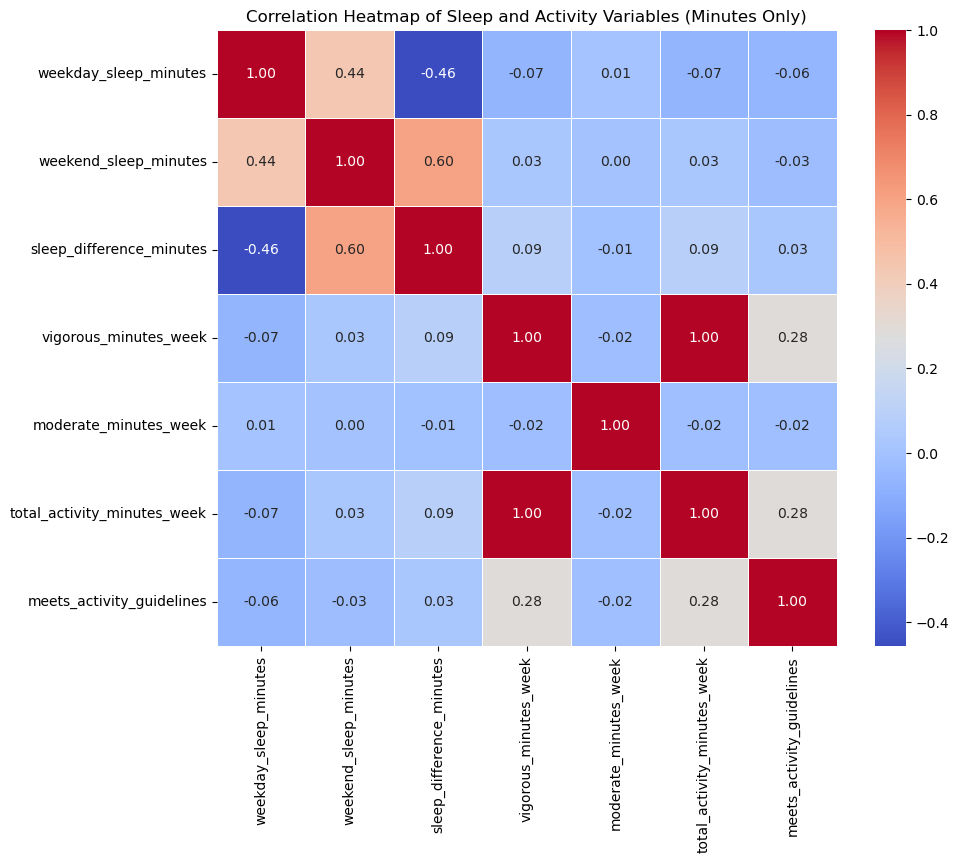

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# remove participant_id
heatmap_df = final_df.drop(columns=["participant_id"])

# keep only numeric columns
numeric_vars = heatmap_df.select_dtypes(include="number")

# drop redundant hour columns (keep minutes instead)
cols_to_drop = [col for col in numeric_vars.columns if "hours" in col.lower()]
numeric_vars = numeric_vars.drop(columns=cols_to_drop)

# correlation matrix
corr_matrix = numeric_vars.corr()

# plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Sleep and Activity Variables (Minutes Only)")
plt.show()

The correlation heatmap depicts the relationships between the sleep and physical activity variables in the dataset. As expected, weekday and weekend sleep hours have a perfect correlation with their corresponding sleep minutes variables as they both represent the same measurements in different units.

From the standpoint of our research question about how **physical activity duration affects sleep duration**, the heatmap illustrates that activity variables (vigorous, moderate, and total activity minutes per week) have weak to no correlations **close to zero** with sleep variables. This suggests there is **little to no strong linear relationship** between physical activity duration and sleep duration in this dataset.

We will have to do a deeper analysis to understand the relationship between both variables and consider that the relationship between activity and sleep is **nonlinear**, influenced by **other factors** such as age or health, or affected by **outliers** in the activity data.


### Scatterplot of Sleep Duration vs Physical Activity Duration
To examine the relationship between physical activity and sleep, we created a scatter plot comparing daily physical activity (in minutes per day) and weekday sleep duration (in minutes per night). Since physical activity was originally recorded as total minutes per week, we converted it to daily minutes by dividing by seven so both variables would be measured on a similar daily scale.

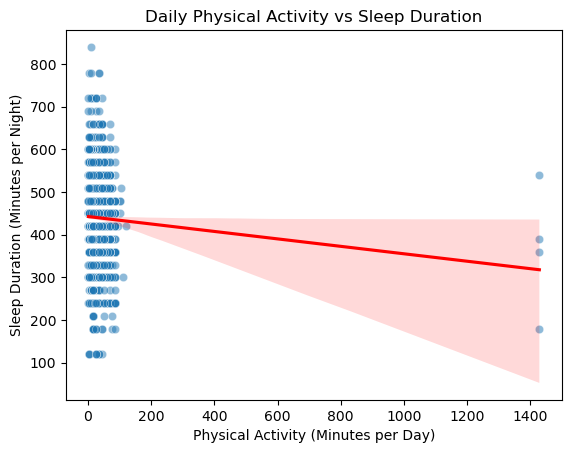

Pearson correlation (r): -0.0696388387973565
p-value: 0.010118645869152365


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Convert weekly activity → daily
final_df["activity_minutes_day"] = final_df["total_activity_minutes_week"] / 7

# Create scatterplot + regression line
plt.figure()

sns.scatterplot(
    data=final_df,
    x="activity_minutes_day",
    y="weekday_sleep_minutes",
    alpha=0.5
)

sns.regplot(
    data=final_df,
    x="activity_minutes_day",
    y="weekday_sleep_minutes",
    scatter=False,
    color="red"
)

plt.xlabel("Physical Activity (Minutes per Day)")
plt.ylabel("Sleep Duration (Minutes per Night)")
plt.title("Daily Physical Activity vs Sleep Duration")

plt.show()


# Drop missing values
df_clean = final_df[["activity_minutes_day", "weekday_sleep_minutes"]].dropna()

# Pearson correlation (r value + p-value)
r, p = pearsonr(
    df_clean["activity_minutes_day"],
    df_clean["weekday_sleep_minutes"]
)

print("Pearson correlation (r):", r)
print("p-value:", p)

The information on the scatterplot does not confirm our hypothesis that an increase in physical activity is correlated with an increase in the duration of sleep. The points on the scatterplot do not follow a linear trend; instead, they are randomly scattered, showing neither a trend nor a direction. 

The points representing people with low as well as high physical activity show a wide variation in the duration of sleep, which means that the level of physical activity is not a determining factor in the duration of sleep. 

In order to further quantify the relationship between physical activity and sleep duration, the linear regression line was also provided in the scatterplot. The linear regression line was found to have a slight slope downwards, which indicated that the relationship between physical activity and sleep duration was negative but very weak. This was also supported by the correlation coefficient between the two variables, which was found to be r = -0.0696, very close to zero, indicating that the relationship between the two variables was extremely weak but negative.

Even though the relationship was found to be significant at p = 0.0101, the relationship was extremely weak, indicating that physical activity explained very little of the variation in sleep duration. From the correlation coefficient and the linear regression line, the relationship between physical activity and sleep duration was found to be insignificant.

The scatterplot shows that physical activity has little, if any, effect on the duration of sleep, thus refuting our hypothesis that an increase in the duration of sleep is correlated with an increase in the level of physical activity.

## Ethics


This project uses publicly available data from the National Health and Nutrition Examination Survey (NHANES) 2017–2018 cycle, conducted by the Centers for Disease Control and Prevention (CDC). The data are fully anonymized and do not contain any personally identifiable information. Participants’ identities are protected, and the data were collected under strict ethical and privacy standards. Because of this, privacy risks are minimal. The datasets are being used strictly for academic purposes.

The goal of this analysis is to explore statistical relationships between sleep duration and physical activity patterns, not to make medical claims, provide treatment recommendations, or establish causation. All findings will be presented at the population level. We will avoid overgeneralizing results or suggesting that certain demographic characteristics such as age, gender, or body measurements directly determine sleep outcomes.

We also recognize that sleep and health-related measures are influenced by many complex factors, including genetics, environment, lifestyle, and socioeconomic conditions. Any associations found in the data will be discussed carefully to avoid stigmatizing or stereotyping individuals or groups. The intention is to understand patterns, not to assign blame or make assumptions.

Throughout the project, all data cleaning steps, transformations, and analytical decisions will be clearly documented to ensure transparency and integrity. Any limitations, such as self-reported measures or missing data, will be openly acknowledged. Overall, the analysis will be conducted thoughtfully and responsibly, with respect for the individuals represented in the dataset.


## Discussion and Conclusion

### 1. Summarize the important results you made

Based on the scatterplot and heatmap, we found that there is a weak relationship between the physical activity and sleep duration which disproves our hypothesis. When looking at the scatterplot, you can see a weak correlation between the physical activity and sleep duration. There is a wide vertical spread of sleep duration for any level of physical activity showing that it is more random than expected. This cross-sectional example implies that the amount of exercise people get in a day does not determine or predict how long they're gonna be in a sleeping stage that night. 

Although this finding disproves the direct correlation of exercise predicting how much sleep one gets during the night, it doesn’t necessarily mean that exercise is irrelevant to sleep overall; it’s just portraying that sleep is a complex activity, being a health outcome that is affected by many factors at once.

---

### 2. This is a good time to refer back to your Background section and review how this work extended the previous stuff

As mentioned in the background section, factors like stress reduction, metabolic improvements, and circadian rhythm regulation that result from exercise are linked to sleep duration. Research cited in our background section from before has implied that people who exercise on a consistent basis sleep longer and more consistently than those who don’t exercise as much. In addition, prior research in the background section about a study done on undergraduate students in China discovered that low activity/exercise levels and high screen time levels before sleep were correlated with bad sleep. Essentially, our analyses engaged directly with these facts & ideas in the background section by quantifying the relationship between physical activity and sleep in a large sample of adults. By quantifying with a sample like this, we have extended the scope of work done in the past in the background section, going beyond just college students and entering a broader cross-section of the adult population in the US.

Although a lot of prior research and studies have supported a strong relationship/correlation between exercise and sleep, our scatterplots and findings imply that the relationship might not have been as strong as it seems. Majority of the prior studies in the background were measuring exercise as a long-term thing and used objective metrics to calculate sleep, but our dataset and findings were short-term and captured a single week of self-reported behavior. So essentially these findings don't necessarily contradict the findings in the earlier research in the background section, but they do provide some distinct differences between how much exercise exactly affects your sleep. The work we did paints a picture and portrays the specific conditions under which those conclusions about physical activity & sleep may or may not stand. 


---

### 3. Try to bring all the different results together into a bigger picture... what have we learned?

When we put everything together, the main takeaway from this project is that sleep duration is not something you can explain with just one factor. It is influenced by a bunch of different things at the same time. Our scatterplot showed that physical activity by itself does not explain much of the variation in how long people sleep. At the same time, the correlation heatmap suggested that things like BMI have a stronger relationship with sleep compared to activity.

Looking at this with our research question and hypothesis in mind, it becomes clear that there is not a strong or consistent link between exercise and sleep duration on its own. Instead, it looks more like a mix of interacting factors where physical activity is just one piece of the bigger picture. This lines up with what we talked about in the background, where sleep is affected by behavioral, physiological, and lifestyle factors all at once, not just one variable.

What this project really shows is not just something about sleep, but also about how this kind of data works. Large datasets like NHANES are great for spotting general patterns across a population, but they are not as good at picking up more detailed relationships. The weak correlation we found could mean that physical activity is not a strong predictor of sleep duration by itself, or it could be because of the way the data was collected, the fact that it is cross-sectional, or the noise from self-reported responses. 

Either way, the main takeaway is that if we want to really understand sleep, we cannot just look at simple one-to-one relationships. We need to use models that consider multiple factors at the same time, since sleep is shaped by a combination of different influences.


---

### 4. Often what we learned is confusing. Discuss if there are contradictory results and how that might have happened

In the scatterplot, something we found confusing is the fact that there is a p-value that says it is significant. Oftentimes, we consider the p-value, which is less than 0.05, and this shows that it is statistically significant. However, when looking at the scatterplot visually, there seems to be no positive correlation between physical activity and sleep duration and it appears rather random. 

This is when we looked into our study more and found that there are around 1300 participants, which means that small effects will show up in the study (certain people will have better sleep due to increased physical activity), but overall, there is visually no strong correlation, and the r-value certainly disproves our hypothesis, since an r-value being close to 1 would support our hypothesis. As a result, these statistics still show that the relationship is extremely weak, and this helped us understand the difference between statistical and practical significance.

---

### 5. Discuss the limitations of your work

The biggest limitations in this project come from the data itself. Both datasets are based  on self-reported responses, which are known to have bias since people usually overestimate how much they exercise and how much they sleep compared to actual measurements like wearable trackers. Because both of these are likely inflated, it makes it hard to tell if the weak correlation we found actually means there is no relationship, or if both variables are just being overreported and hiding a real pattern.

The NHANES dataset is meant to represent the general population, but it still leaves out certain groups like military personnel, people in hospitals, and those in long-term care. These groups could have very different activity and sleep patterns, so that is another limitation. 

Another important issue is that the data is cross-sectional, meaning it is just one snapshot in time. Because of that, we cannot say whether changes in physical activity actually cause changes in sleep for the same person over time. Also, since the PAQ_J dataset only gives weekly activity and not daily breakdowns, we had to assume activity is spread evenly across all seven days. That is not very realistic and limits how precise our daily estimates can be.


---

### 6. If you would like, you can also say what the next steps in this investigation might be if the work was to continue outside this class

If this project were continued, the best improvement would be to use objective data from wearable devices instead of self-reported responses. Wearables can track both activity and sleep continuously and much more accurately, especially on a day-to-day level. It would also be better to move from a cross-sectional design to a longitudinal study that follows the same people over several months. That way, we could actually see if changes in exercise lead to changes in sleep over time and also account for things like seasonal differences. 

For analysis, future work should go beyond just looking at simple correlations and instead use models like regression that can control for other factors such as age, BMI, blood pressure, and job type. It would also help to expand how sleep is measured. Instead of just looking at duration, we could include things like sleep quality, how long it takes to fall asleep, and how rested people feel. That would give a more complete understanding of how physical activity affects sleep across different groups. 

